In [ ]:
!pip -q install transformers torchaudio scikit-learn pandas tqdm

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 13.9 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import transformers
print(transformers.__version__)

5.12.0


In [ ]:
import os
import shutil
import random

# תיקיית מקור
SOURCE_DIR = "/content/drive/MyDrive/balanced_data"

# תיקיית יעד חדשה ונקייה
OUTPUT_DIR = "/content/drive/MyDrive/dataset_split"

split_ratio = 0.8
random.seed(42)

AUDIO_EXTS = (".wav", ".flac", ".mp3", ".m4a", ".ogg")

# אם תיקיית היעד כבר קיימת - מוחקים כדי ליצור מחדש נקי
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

def split_folder(src_folder, train_folder, test_folder):
    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)

    files = [
        f for f in os.listdir(src_folder)
        if os.path.isfile(os.path.join(src_folder, f)) and f.lower().endswith(AUDIO_EXTS)
    ]

    random.shuffle(files)
    split_index = int(len(files) * split_ratio)

    train_files = files[:split_index]
    test_files = files[split_index:]

    for f in train_files:
        shutil.copy2(
            os.path.join(src_folder, f),
            os.path.join(train_folder, f)
        )

    for f in test_files:
        shutil.copy2(
            os.path.join(src_folder, f),
            os.path.join(test_folder, f)
        )

# -------- real --------
split_folder(
    os.path.join(SOURCE_DIR, "real"),
    os.path.join(OUTPUT_DIR, "train", "real"),
    os.path.join(OUTPUT_DIR, "test", "real")
)

# -------- fake --------
fake_root = os.path.join(SOURCE_DIR, "fake")

attack_types = [
    d for d in os.listdir(fake_root)
    if os.path.isdir(os.path.join(fake_root, d))
]

for attack in attack_types:
    src = os.path.join(fake_root, attack)

    train_dest = os.path.join(OUTPUT_DIR, "train", "fake", attack)
    test_dest  = os.path.join(OUTPUT_DIR, "test", "fake", attack)

    split_folder(src, train_dest, test_dest)

print("Split completed successfully!")
print("New dataset created at:", OUTPUT_DIR)

Split completed successfully!
New dataset created at: /content/drive/MyDrive/dataset_split


In [ ]:
print("Detected attack types:", attack_types)

Detected attack types: ['unknown', 'waveform_concatenation', 'neural_vocoder_nonautoregressive', 'neural_vocoder_autoregressive', 'traditional_vocoder', 'elevenlabs_fake']


In [ ]:
import os

DATA_ROOT = "/content/drive/MyDrive/dataset_split"

print(os.listdir(DATA_ROOT))
print(os.listdir(os.path.join(DATA_ROOT, "train")))
print(os.listdir(os.path.join(DATA_ROOT, "train", "real"))[:5])
print(os.listdir(os.path.join(DATA_ROOT, "train", "fake")))

['train', 'test']
['real', 'fake']
['DF_E_2568761.flac', 'DF_E_2126953.flac', 'DF_E_2457477.flac', 'DF_E_2118513.flac', 'DF_E_2337613.flac']
['unknown', 'waveform_concatenation', 'neural_vocoder_nonautoregressive', 'neural_vocoder_autoregressive', 'traditional_vocoder', 'elevenlabs_fake']


In [ ]:
# ==========================================
# Install + Imports
# ==========================================

!pip install -q torch torchaudio transformers tqdm scikit-learn pandas matplotlib seaborn

import os
import json
import random

import numpy as np
import pandas as pd

import torch
import torchaudio

from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import AdamW

from transformers import Wav2Vec2ForSequenceClassification

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Copying dataset from Google Drive to local storage...")

if not os.path.exists("/content/dataset_split"):
    !cp -r "/content/drive/MyDrive/dataset_split" "/content/"
    print("Dataset copied successfully!")
else:
    print("Dataset already exists in /content/dataset_split")

# ==========================================
# CONFIG
# ==========================================

CONFIG = {
    "experiment_name": "wav2vec2_exp_001",

    "seed": 42,

    "target_sample_rate": 16000,
    "max_duration": 4,

    "batch_size": 4,
    "epochs": 5,
    "learning_rate": 1e-5,
    "weight_decay": 0.01,

    "val_ratio": 0.15,

    "model_name": "facebook/wav2vec2-base",

    "freeze_feature_extractor": True,
    "freeze_encoder": False,

    "train_dir": "/content/dataset_split/train",
    "test_dir": "/content/dataset_split/test",

    "results_dir": "/content/results"
}

# ==========================================
# Seeds
# ==========================================

SEED = CONFIG["seed"]

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ==========================================
# Derived values
# ==========================================

TARGET_SAMPLE_RATE = CONFIG["target_sample_rate"]
MAX_DURATION = CONFIG["max_duration"]
MAX_LENGTH = TARGET_SAMPLE_RATE * MAX_DURATION

BATCH_SIZE = CONFIG["batch_size"]
EPOCHS = CONFIG["epochs"]
LR = CONFIG["learning_rate"]
VAL_RATIO = CONFIG["val_ratio"]

TRAIN_DIR = CONFIG["train_dir"]
TEST_DIR = CONFIG["test_dir"]

EXPERIMENT_DIR = os.path.join(
    CONFIG["results_dir"],
    CONFIG["experiment_name"]
)

os.makedirs(EXPERIMENT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    EXPERIMENT_DIR,
    "best_model.pt"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")
print(f"Experiment: {CONFIG['experiment_name']}")
print(f"Results folder: {EXPERIMENT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Experiment: wav2vec2_exp_001
Results folder: /content/results/wav2vec2_exp_001


In [ ]:
# ==========================================
# Dataset - Wav2Vec2
# ==========================================

class DeepfakeAudioDataset(Dataset):
    def __init__(
        self,
        root_dir,
        target_sample_rate=16000,
        max_duration=4,
        mode="train"
    ):
        self.samples = []
        self.target_sample_rate = target_sample_rate
        self.max_length = target_sample_rate * max_duration
        self.mode = mode

        self.valid_exts = (
            ".wav",
            ".mp3",
            ".flac",
            ".m4a"
        )

        # real = 0
        real_dir = os.path.join(root_dir, "real")

        if os.path.exists(real_dir):
            for file in os.listdir(real_dir):
                if file.lower().endswith(self.valid_exts):
                    self.samples.append({
                        "path": os.path.join(real_dir, file),
                        "label": 0,
                        "attack_type": "real"
                    })

        # fake = 1
        fake_dir = os.path.join(root_dir, "fake")

        if os.path.exists(fake_dir):
            for attack_folder in os.listdir(fake_dir):

                attack_path = os.path.join(
                    fake_dir,
                    attack_folder
                )

                if os.path.isdir(attack_path):

                    for subdir, _, files in os.walk(attack_path):

                        for file in files:

                            if file.lower().endswith(
                                self.valid_exts
                            ):
                                self.samples.append({
                                    "path": os.path.join(
                                        subdir,
                                        file
                                    ),
                                    "label": 1,
                                    "attack_type": attack_folder
                                })

        self.filepaths = [s["path"] for s in self.samples]
        self.labels = [s["label"] for s in self.samples]
        self.attack_types = [s["attack_type"] for s in self.samples]

        print(
            f"[{mode}] Loaded "
            f"{len(self.samples)} files "
            f"from {root_dir}"
        )

    def __len__(self):
        return len(self.samples)

    def _load_audio(self, filepath):
        waveform, sample_rate = torchaudio.load(filepath)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(
                dim=0,
                keepdim=True
            )

        if sample_rate != self.target_sample_rate:

            resampler = torchaudio.transforms.Resample(
                orig_freq=sample_rate,
                new_freq=self.target_sample_rate
            )

            waveform = resampler(waveform)

        return waveform.squeeze(0)

    def _crop_or_pad(self, waveform):

        length = waveform.shape[0]

        if length > self.max_length:

            if self.mode == "train":
                start = random.randint(
                    0,
                    length - self.max_length
                )
            else:
                start = (
                    length - self.max_length
                ) // 2

            waveform = waveform[
                start:start + self.max_length
            ]

            attention_mask = torch.ones(
                self.max_length,
                dtype=torch.long
            )

        else:

            pad_length = (
                self.max_length - length
            )

            waveform = torch.nn.functional.pad(
                waveform,
                (0, pad_length)
            )

            attention_mask = torch.cat([
                torch.ones(
                    length,
                    dtype=torch.long
                ),
                torch.zeros(
                    pad_length,
                    dtype=torch.long
                )
            ])

        return waveform, attention_mask

    def __getitem__(self, idx):

        sample = self.samples[idx]

        waveform = self._load_audio(
            sample["path"]
        )

        waveform, attention_mask = (
            self._crop_or_pad(waveform)
        )

        return {
            "input_values": waveform,
            "attention_mask": attention_mask,
            "labels": torch.tensor(
                sample["label"],
                dtype=torch.long
            ),

            "path": sample["path"],
            "attack_type": sample["attack_type"]
        }

In [ ]:
# ==========================================
# 2. פונקציה לפיצול מאוזן לפי תיקיות התקיפה
# ==========================================
def stratified_split_by_attack(dataset, val_ratio=0.15, seed=42):
    random.seed(seed)

    group_to_indices = {}

    for idx, attack_type in enumerate(dataset.attack_types):
        if attack_type not in group_to_indices:
            group_to_indices[attack_type] = []
        group_to_indices[attack_type].append(idx)

    train_indices = []
    val_indices = []

    print("Split summary by class/attack type:")
    print("-" * 50)

    for group_name, indices in group_to_indices.items():
        random.shuffle(indices)

        n_val = max(1, int(len(indices) * val_ratio)) if len(indices) > 1 else 0

        val_group = indices[:n_val]
        train_group = indices[n_val:]

        # אם בגלל גודל קטן הכל נכנס ל-val, נשאיר לפחות דגימה אחת ל-train
        if len(train_group) == 0 and len(val_group) > 0:
            train_group = [val_group.pop()]

        train_indices.extend(train_group)
        val_indices.extend(val_group)

        print(f"{group_name:35s} train={len(train_group):4d} | val={len(val_group):4d} | total={len(indices):4d}")

    random.shuffle(train_indices)
    random.shuffle(val_indices)

    return train_indices, val_indices

In [ ]:
# ==========================================
# יצירת datasets + dataloaders - Wav2Vec2
# ==========================================

full_train_dataset_for_train = DeepfakeAudioDataset(
    root_dir=TRAIN_DIR,
    target_sample_rate=TARGET_SAMPLE_RATE,
    max_duration=MAX_DURATION,
    mode='train'
)

full_train_dataset_for_val = DeepfakeAudioDataset(
    root_dir=TRAIN_DIR,
    target_sample_rate=TARGET_SAMPLE_RATE,
    max_duration=MAX_DURATION,
    mode='val'
)

test_dataset = DeepfakeAudioDataset(
    root_dir=TEST_DIR,
    target_sample_rate=TARGET_SAMPLE_RATE,
    max_duration=MAX_DURATION,
    mode='test'
)

train_indices, val_indices = stratified_split_by_attack(
    full_train_dataset_for_train,
    val_ratio=VAL_RATIO,
    seed=SEED
)

train_dataset = Subset(full_train_dataset_for_train, train_indices)
val_dataset = Subset(full_train_dataset_for_val, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataset sizes:")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

print("\nUnique attack types:")
print(sorted(set(full_train_dataset_for_train.attack_types)))

[train] Loaded 10625 files from /content/drive/MyDrive/dataset_split/train
[val] Loaded 10625 files from /content/drive/MyDrive/dataset_split/train
[test] Loaded 2661 files from /content/drive/MyDrive/dataset_split/test
Split summary by class/attack type:
--------------------------------------------------
real                                train=4517 | val= 797 | total=5314
unknown                             train= 753 | val= 132 | total= 885
waveform_concatenation              train= 753 | val= 132 | total= 885
neural_vocoder_nonautoregressive    train= 753 | val= 132 | total= 885
neural_vocoder_autoregressive       train= 753 | val= 132 | total= 885
traditional_vocoder                 train= 753 | val= 132 | total= 885
elevenlabs_fake                     train= 754 | val= 132 | total= 886

Dataset sizes:
Train samples: 9036
Val samples:   1589
Test samples:  2661

Unique attack types:
['elevenlabs_fake', 'neural_vocoder_autoregressive', 'neural_vocoder_nonautoregressive', 'real', '

In [ ]:
# ==========================================
# טעינת מודל Wav2Vec2
# ==========================================

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=2
)

# ==========================================
# Freeze Feature Extractor
# ==========================================

if CONFIG["freeze_feature_extractor"]:
    print("Freezing feature extractor...")
    model.freeze_feature_encoder()

# ==========================================
# Freeze Encoder
# ==========================================

if CONFIG["freeze_encoder"]:
    print("Freezing Wav2Vec2 encoder...")

    for param in model.wav2vec2.encoder.parameters():
        param.requires_grad = False

model = model.to(device)

# ==========================================
# Optimizer
# ==========================================

trainable_params = filter(
    lambda p: p.requires_grad,
    model.parameters()
)

optimizer = AdamW(
    trainable_params,
    lr=LR,
    weight_decay=CONFIG["weight_decay"]
)

print("\nModel loaded successfully")
print("Model:", CONFIG["model_name"])
print("Learning Rate:", LR)
print("Freeze Feature Extractor:", CONFIG["freeze_feature_extractor"])
print("Freeze Encoder:", CONFIG["freeze_encoder"])

total_params = sum(p.numel() for p in model.parameters())

trainable_params_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params_count:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing feature extractor...

Model loaded successfully
Model: facebook/wav2vec2-base
Learning Rate: 1e-05
Freeze Feature Extractor: True
Freeze Encoder: False

Total Parameters: 94,569,090
Trainable Parameters: 90,368,642


In [ ]:
# ==========================================
# פונקציית הערכה - Wav2Vec2
# ==========================================

def evaluate_model_wav2vec2(model, dataloader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []
    all_attack_types = []
    all_paths = []

    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_values=input_values,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            probs = torch.softmax(logits, dim=-1)[:, 1]
            preds = torch.argmax(logits, dim=-1)

            total_loss += loss.item()

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

            if "attack_type" in batch:
                all_attack_types.extend(batch["attack_type"])

            if "path" in batch:
                all_paths.extend(batch["path"])

    return {
        "loss": total_loss / len(dataloader),
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_recall_fscore_support(
            all_labels, all_preds, average="binary", zero_division=0
        )[0],
        "recall": precision_recall_fscore_support(
            all_labels, all_preds, average="binary", zero_division=0
        )[1],
        "f1": precision_recall_fscore_support(
            all_labels, all_preds, average="binary", zero_division=0
        )[2],
        "auc": roc_auc_score(all_labels, all_probs),
        "confusion_matrix": confusion_matrix(all_labels, all_preds),
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "attack_types": all_attack_types,
        "paths": all_paths
    }

In [ ]:
# ==========================================
# לולאת אימון - Wav2Vec2
# ==========================================

best_val_f1 = 0.0
history = []

for epoch in range(EPOCHS):

    model.train()

    total_train_loss = 0.0
    train_preds = []
    train_labels = []

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        leave=True
    )

    for batch in loop:

        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_values=input_values,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        preds = torch.argmax(logits, dim=-1)

        train_preds.extend(
            preds.detach().cpu().numpy().tolist()
        )

        train_labels.extend(
            labels.detach().cpu().numpy().tolist()
        )

        loop.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = total_train_loss / len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    val_metrics = evaluate_model_wav2vec2(
        model,
        val_loader,
        device
    )

    epoch_result = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    }

    history.append(epoch_result)

    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val Precision: {val_metrics['precision']:.4f}")
    print(f"Val Recall: {val_metrics['recall']:.4f}")
    print(f"Val F1: {val_metrics['f1']:.4f}")
    print(f"Val ROC-AUC: {val_metrics['auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:

        best_val_f1 = val_metrics["f1"]

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("Best model saved")

history_df = pd.DataFrame(history)

history_path = os.path.join(
    EXPERIMENT_DIR,
    "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print("\nTraining complete!")
print("Best validation F1:", best_val_f1)

Epoch 1/5: 100%|██████████| 2259/2259 [11:11<00:00,  3.37it/s, loss=0.0055]



=== Epoch 1/5 ===
Train Loss: 0.1568
Train Accuracy: 0.9347
Val Accuracy: 0.9679
Val Precision: 0.9781
Val Recall: 0.9571
Val F1: 0.9675
Val ROC-AUC: 0.9980
Best model saved


Epoch 2/5: 100%|██████████| 2259/2259 [11:11<00:00,  3.36it/s, loss=0.0018]



=== Epoch 2/5 ===
Train Loss: 0.0485
Train Accuracy: 0.9837
Val Accuracy: 0.9824
Val Precision: 0.9974
Val Recall: 0.9672
Val F1: 0.9821
Val ROC-AUC: 0.9989
Best model saved


Epoch 3/5: 100%|██████████| 2259/2259 [11:11<00:00,  3.37it/s, loss=0.0085]



=== Epoch 3/5 ===
Train Loss: 0.0345
Train Accuracy: 0.9880
Val Accuracy: 0.9729
Val Precision: 1.0000
Val Recall: 0.9457
Val F1: 0.9721
Val ROC-AUC: 0.9993


Epoch 4/5: 100%|██████████| 2259/2259 [11:10<00:00,  3.37it/s, loss=0.0006]



=== Epoch 4/5 ===
Train Loss: 0.0233
Train Accuracy: 0.9930
Val Accuracy: 0.9950
Val Precision: 0.9937
Val Recall: 0.9962
Val F1: 0.9950
Val ROC-AUC: 0.9998
Best model saved


Epoch 5/5: 100%|██████████| 2259/2259 [11:12<00:00,  3.36it/s, loss=0.0005]



=== Epoch 5/5 ===
Train Loss: 0.0228
Train Accuracy: 0.9926
Val Accuracy: 0.9918
Val Precision: 1.0000
Val Recall: 0.9836
Val F1: 0.9917
Val ROC-AUC: 0.9998

Training complete!
Best validation F1: 0.9949558638083228


In [ ]:
# ==========================================
# בדיקה על Test - Wav2Vec2
# ==========================================

model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)

test_metrics = evaluate_model_wav2vec2(
    model,
    test_loader,
    device
)

print("\n=== TEST RESULTS ===")
print(f"Loss:      {test_metrics['loss']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-score:  {test_metrics['f1']:.4f}")
print(f"ROC-AUC:   {test_metrics['auc']:.4f}")
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

test_summary = {
    "experiment_name": CONFIG["experiment_name"],
    "model_name": CONFIG["model_name"],
    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "test_loss": test_metrics["loss"],
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"],
    "confusion_matrix": test_metrics["confusion_matrix"].tolist()
}

summary_df = pd.DataFrame([test_summary])

summary_df.to_csv(
    "/content/drive/MyDrive/final_model_comparison/final_presentation_summary/wavlm_summary.csv",
    index=False
)


=== TEST RESULTS ===
Loss:      0.0345
Accuracy:  0.9925
Precision: 0.9932
Recall:    0.9917
F1-score:  0.9925
ROC-AUC:   0.9996
Confusion Matrix:
[[1320    9]
 [  11 1321]]


In [ ]:
# ==========================================
# שמירת תוצאות הניסוי לטבלת השוואה
# ==========================================

experiment_result = pd.DataFrame([{
    "experiment_name": CONFIG["experiment_name"],
    "model_name": CONFIG["model_name"],

    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,

    "freeze_feature_extractor": CONFIG["freeze_feature_extractor"],
    "freeze_encoder": CONFIG["freeze_encoder"],

    "best_val_f1": best_val_f1,

    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"]
}])

results_csv = os.path.join(
    CONFIG["results_dir"],
    "experiments.csv"
)

if os.path.exists(results_csv):

    previous_results = pd.read_csv(results_csv)

    experiment_result = pd.concat(
        [previous_results, experiment_result],
        ignore_index=True
    )

experiment_result.to_csv(
    results_csv,
    index=False
)

print("Experiment added to:")
print(results_csv)

display(
    experiment_result.sort_values(
        by="test_f1",
        ascending=False
    )
)

Experiment added to:
/content/results/experiments.csv


,experiment_name,model_name,learning_rate,batch_size,epochs,freeze_feature_extractor,freeze_encoder,best_val_f1,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,wav2vec2_exp_001,facebook/wav2vec2-base,0.00001,4,5,True,False,0.994956,0.992484,0.993233,0.991742,0.992487,0.999599


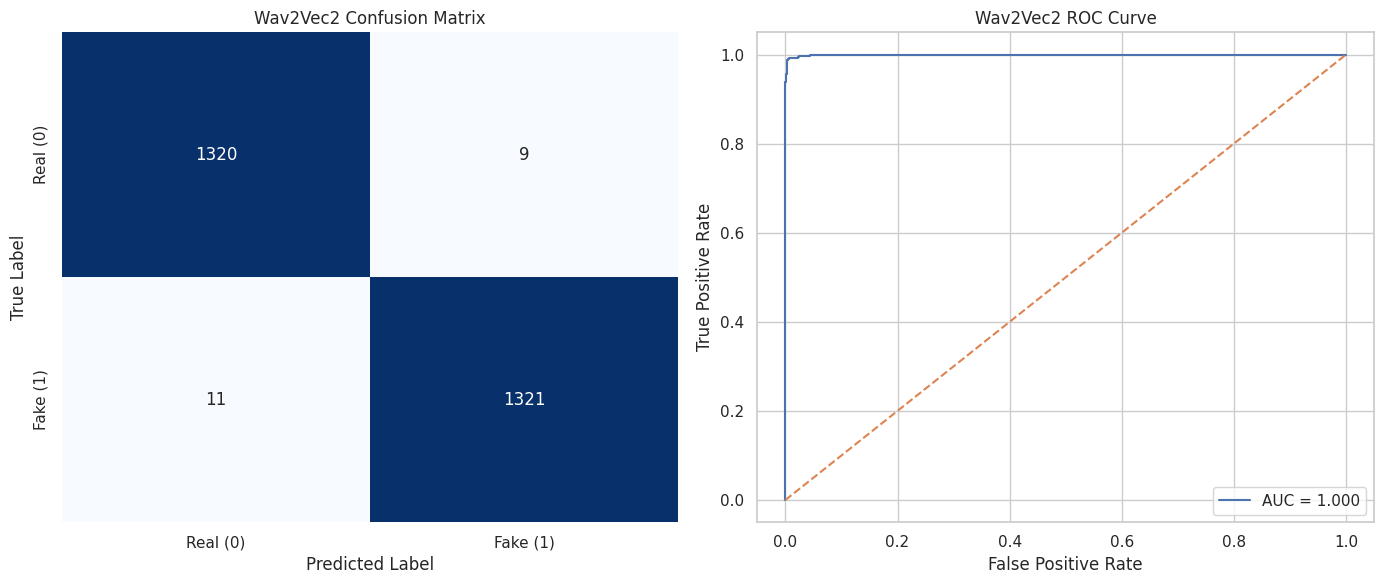

Plots saved to: /content/results/wav2vec2_exp_001/test_plots.png


In [ ]:
# ==========================================
# שמירת גרפים לניסוי Wav2Vec2
# ==========================================

def save_test_plots_wav2vec2(test_metrics, experiment_dir):
    labels = test_metrics["labels"]
    preds = test_metrics["preds"]
    probs = test_metrics["probs"]

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    cm = confusion_matrix(labels, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        cbar=False,
        xticklabels=["Real (0)", "Fake (1)"],
        yticklabels=["Real (0)", "Fake (1)"]
    )

    axes[0].set_title("Wav2Vec2 Confusion Matrix")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--")

    axes[1].set_title("Wav2Vec2 ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")

    plt.tight_layout()

    plot_path = os.path.join(
        experiment_dir,
        "test_plots.png"
    )

    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Plots saved to:", plot_path)


save_test_plots_wav2vec2(
    test_metrics,
    EXPERIMENT_DIR
)

In [ ]:
# ==========================================
# דוח מפורט לפי סוג תקיפה - Wav2Vec2
# ==========================================

def create_attack_type_report_wav2vec2(
    test_metrics,
    experiment_dir
):
    results_df = pd.DataFrame({
        "path": test_metrics["paths"],
        "attack_type": test_metrics["attack_types"],
        "label": test_metrics["labels"],
        "prediction": test_metrics["preds"],
        "p_fake": test_metrics["probs"]
    })

    results_df["correct"] = (
        results_df["label"] ==
        results_df["prediction"]
    )

    detailed_path = os.path.join(
        experiment_dir,
        "detailed_predictions.csv"
    )

    results_df.to_csv(
        detailed_path,
        index=False
    )

    summary = (
        results_df
        .groupby("attack_type")
        .agg(
            total_files=("label", "count"),
            correct_predictions=("correct", "sum"),
            wrong_predictions=("correct", lambda x: (~x).sum()),
            detected_as_fake=("prediction", lambda x: (x == 1).sum()),
            missed_as_real=("prediction", lambda x: (x == 0).sum()),
            accuracy=("correct", "mean")
        )
        .reset_index()
    )

    summary_path = os.path.join(
        experiment_dir,
        "attack_type_summary.csv"
    )

    summary.to_csv(
        summary_path,
        index=False
    )

    print("Detailed predictions saved to:")
    print(detailed_path)

    print("Attack type summary saved to:")
    print(summary_path)

    return results_df, summary


detailed_predictions, attack_type_summary = (
    create_attack_type_report_wav2vec2(
        test_metrics,
        EXPERIMENT_DIR
    )
)

display(attack_type_summary)

Detailed predictions saved to:
/content/results/wav2vec2_exp_001/detailed_predictions.csv
Attack type summary saved to:
/content/results/wav2vec2_exp_001/attack_type_summary.csv


,attack_type,total_files,correct_predictions,wrong_predictions,detected_as_fake,missed_as_real,accuracy
0,elevenlabs_fake,222,221,1,221,1,0.995495
1,neural_vocoder_autoregressive,222,215,7,215,7,0.968468
2,neural_vocoder_nonautoregressive,222,222,0,222,0,1.000000
3,real,1329,1320,9,9,1320,0.993228
4,traditional_vocoder,222,219,3,219,3,0.986486
5,unknown,222,222,0,222,0,1.000000
6,waveform_concatenation,222,222,0,222,0,1.000000


In [ ]:
# ==========================================
# חיזוי על קובץ אודיו יחיד - Wav2Vec2
# ==========================================

def predict_single_file_wav2vec2(
    file_path,
    model,
    device,
    config
):
    model.eval()

    target_sample_rate = config["target_sample_rate"]
    max_duration = config["max_duration"]
    max_length = target_sample_rate * max_duration

    try:
        waveform, sample_rate = torchaudio.load(file_path)
    except Exception as e:
        return {
            "error": f"Could not load audio file: {e}"
        }

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sample_rate != target_sample_rate:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate,
            new_freq=target_sample_rate
        )
        waveform = resampler(waveform)

    waveform = waveform.squeeze(0)
    length = waveform.shape[0]

    if length > max_length:
        start = (length - max_length) // 2
        waveform = waveform[start:start + max_length]
        attention_mask = torch.ones(max_length, dtype=torch.long)
    else:
        pad_length = max_length - length
        waveform = torch.nn.functional.pad(waveform, (0, pad_length))

        attention_mask = torch.cat([
            torch.ones(length, dtype=torch.long),
            torch.zeros(pad_length, dtype=torch.long)
        ])

    input_values = waveform.unsqueeze(0).to(device)
    attention_mask = attention_mask.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(
            input_values=input_values,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]

    pred_class = torch.argmax(probs).item()
    label = "FAKE" if pred_class == 1 else "REAL"

    return {
        "file_path": file_path,
        "prediction": label,
        "p_real": float(probs[0].item()),
        "p_fake": float(probs[1].item())
    }

In [ ]:
file_to_test = "/content/ElevenLabs_2026-03-09T13_31_32_Titan - Deep, Bold, and Powerful_pvc_sp100_s34_sb75_se44_b_m2.mp3"

result = predict_single_file_wav2vec2(
    file_path=file_to_test,
    model=model,
    device=device,
    config=CONFIG
)

print("Prediction:", result["prediction"])
print(f"Real Probability: {result['p_real']:.4f}")
print(f"Fake Probability: {result['p_fake']:.4f}")

Prediction: FAKE
Real Probability: 0.0414
Fake Probability: 0.9586
